In [57]:
import pandas as pd

In [74]:
import os

os.makedirs('tracking-progress-elementary', exist_ok=True)
os.chdir('tracking-progress-elementary')


In [75]:
import sys
from pathlib import Path
import subprocess

venv_dir = Path(".venv")
if not venv_dir.exists():
    subprocess.run([sys.executable, "-m", "venv", str(venv_dir)], check=True)

venv_python = venv_dir / ("Scripts" if sys.platform == "win32" else "bin") / "python"
subprocess.run(
    [str(venv_python), "-m", "pip", "install", "pandas", "numpy", "matplotlib", "seaborn", "jupyter", "ipykernel"],
    check=True,
)

with open("requirements.txt", "w", encoding="utf-8") as f:
    subprocess.run([str(venv_python), "-m", "pip", "freeze"], check=True, stdout=f)

In [104]:
import sqlite3, pandas as pd
from pathlib import Path
import importlib.util
import sys

# Locate a local clean.py in the notebook/project tree (avoid site-packages)
clean_path = None
for p in Path('.').rglob('clean.py'):
    if 'site-packages' in str(p):
        continue
    clean_path = p
    break

if clean_path is None:
    # fallback to standard import (will raise the original error if wrong module is on sys.path)
    for parent_dir in [Path.cwd()] + list(Path.cwd().parents):
        candidate = parent_dir / "clean.py"
        if candidate.exists() and "site-packages" not in str(candidate):
            spec = importlib.util.spec_from_file_location("clean", str(candidate))
            clean = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(clean)
            clean_diagnostics = clean.clean_diagnostics
            clean_school_summary = clean.clean_school_summary
            clean_school_improvement = clean.clean_school_improvement
            break
else:
    spec = importlib.util.spec_from_file_location("clean", str(clean_path))
    clean = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(clean)
    clean_diagnostics = clean.clean_diagnostics
    clean_school_summary = clean.clean_school_summary
    clean_school_improvement = clean.clean_school_improvement

In [12]:
import sqlite3
from pathlib import Path

db_path = "schooldata.db"  # adjust this path to your actual sqlite file
conn = sqlite3.connect(db_path)

query = "SELECT COUNT(*) FROM diagnostic-results_dummy-database_with-behavior_1000rows;"
db_path = "schooldata.db"  # adjust this path to your actual sqlite file
conn = sqlite3.connect(db_path)

query = 'SELECT COUNT(*) FROM "diagnostic-results_dummy-database_with-behavior_1000rows";'
db_path = "schooldata.db"
conn = sqlite3.connect(db_path)

tables = conn.execute(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;"
).fetchall()
print("Available tables:", [t[0] for t in tables])

table_name = "diagnostic-results_dummy-database_with-behavior_1000rows"
if (table_name,) not in tables:
    db_path = Path("schooldata.db")
    if not db_path.exists():
        raise FileNotFoundError(f"Database file not found: {db_path.resolve()}")

    conn = sqlite3.connect(db_path)

    tables = conn.execute(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;"
    ).fetchall()
    table_names = [t[0] for t in tables]
    print("Available tables:", table_names)

    table_name = "diagnostic-results_dummy-database_with-behavior_1000rows"
    if table_name not in table_names:
        db_candidates = [
            db_path,
            Path.cwd() / "schooldata.db",
            Path.cwd().parent / "schooldata.db",
            Path.cwd() / "Notebooks" / "schooldata.db",
            Path.cwd().parent / "Notebooks" / "schooldata.db",
        ]
        db_path = next((p for p in db_candidates if p.exists()), None)

        if db_path is None:
            raise FileNotFoundError(
            f"Database file not found. Checked: {[str(p.resolve()) for p in db_candidates]}"
            )

        conn = sqlite3.connect(str(db_path))
        tables = conn.execute(
            "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;"
        ).fetchall()
        table_names = [t[0] for t in tables]
        print("Available tables:", table_names)

        if table_name not in table_names:
            # Try the known database candidates first. If none contains the target table,
            # search the project tree for any SQLite database that does.
            found_db = None
            found_table_names = []

            for candidate in db_candidates:
                candidate = Path(candidate)
                if not candidate.exists():
                    continue
                try:
                    with sqlite3.connect(str(candidate)) as test_conn:
                        test_tables = test_conn.execute(
                            "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;"
                        ).fetchall()
                        test_table_names = [t[0] for t in test_tables]
                        if table_name in test_table_names:
                            found_db = candidate
                            found_table_names = test_table_names
                            break
                except Exception as exc:
                    print(f"Could not inspect {candidate}: {exc}")

            if found_db is None:
                project_root = Path.cwd().resolve()
                for candidate in sorted(project_root.rglob("*.db")):
                    try:
                        with sqlite3.connect(str(candidate)) as test_conn:
                            test_tables = test_conn.execute(
                                "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;"
                            ).fetchall()
                            test_table_names = [t[0] for t in test_tables]
                            if table_name in test_table_names:
                                found_db = candidate
                                found_table_names = test_table_names
                                break
                    except Exception:
                        continue

Available tables: []
Available tables: []
Available tables: []


In [14]:
import sqlite3
import pandas as pd
# SciPy is not required in this cell, so remove the unused import to avoid ModuleNotFoundError

DB_PATH = "db/capstone.db"


def get_connection():
    """Open a connection to the capstone SQLite database."""
    return sqlite3.connect(DB_PATH)


def summary_stats(df: pd.DataFrame, group_col: str, value_col: str) -> pd.DataFrame:
    """
    Return count/mean/median/std of value_col, grouped by group_col.
    Reused for both the student thread (e.g. group by at_risk_flag)
    and the school thread (e.g. group by federal_classification).
    """
    result = (
        df.groupby(group_col)[value_col]
        .agg(count="count", mean="mean", median="median", std="std")
        .reset_index()
        .round(2)
    )
    return result

In [15]:
def load_student_diagnostics() -> pd.DataFrame:
    conn = get_connection()
    df = pd.read_sql_query("SELECT * FROM student_diagnostics", conn)
    conn.close()
    return df


def load_school_accountability() -> pd.DataFrame:
    conn = get_connection()
    df = pd.read_sql_query(
        """
        SELECT s.*, i.federal_classification, i.years_identified
        FROM school_accountability s
        LEFT JOIN school_improvement i
          ON s.school_code = i.school_code
         AND s.school_year = i.school_year
        """,
        conn,
    )
    conn.close()
    return df

In [16]:
def compute_correlations(student_df: pd.DataFrame, school_df: pd.DataFrame) -> dict:
    """
    Correlation between behavior_index and growth_gap (student thread),
    and between climate_safety_rate and reading_math_rate (school thread).
    """
    student_clean = student_df.dropna(subset=["behavior_index", "growth_gap"])
    r_student, p_student = stats.pearsonr(
        student_clean["behavior_index"], student_clean["growth_gap"]
    )

    school_clean = school_df.dropna(subset=["climate_safety_rate", "reading_math_rate"])
    r_school, p_school = stats.pearsonr(
        school_clean["climate_safety_rate"], school_clean["reading_math_rate"]
    )

    return {
        "student_behavior_vs_growth": {"r": round(r_student, 3), "p": round(p_student, 4)},
        "school_climate_vs_reading_math": {"r": round(r_school, 3), "p": round(p_school, 4)},
    }

In [25]:
from pathlib import Path
import sqlite3

if __name__ == "__main__":
    DB_PATH = Path("db") / "capstone.db"
    if not DB_PATH.exists():
        for base in [Path.cwd(), *Path.cwd().parents]:
            candidate = base / "db" / "capstone.db"
            if candidate.exists():
                DB_PATH = candidate
                break
        else:
            if __name__ == "__main__":
                DB_PATH = Path("db") / "capstone.db"
                if not DB_PATH.exists():
                    for base in [Path.cwd(), *Path.cwd().parents]:
                        candidate = base / "db" / "capstone.db"
                        if candidate.exists():
                            DB_PATH = candidate
                            break
                    else:
                        for base in [Path.cwd(), *Path.cwd().parents]:
                            candidate = base / "schooldata.db"
                            if candidate.exists():
                                DB_PATH = candidate
                                break
                        else:
                            raise FileNotFoundError(
                                "Could not find database file. Checked for db/capstone.db and schooldata.db in cwd and parent directories."
                            )

    def get_connection():
        return sqlite3.connect(str(DB_PATH))
    db_candidates = [
        Path.cwd() / "schooldata.db",
        Path.cwd().parent / "schooldata.db",
        Path.cwd() / "Notebooks" / "schooldata.db",
        Path.cwd().parent / "Notebooks" / "schooldata.db",
    ]
    DB_PATH = next((p for p in db_candidates if p.exists()), None)
    if DB_PATH is None:
        raise FileNotFoundError(
            "Could not find schooldata.db. Checked: "
            f"{[str(p.resolve()) for p in db_candidates]}"
        )

In [29]:
import os
import subprocess
import sys
from pathlib import Path

for base in [Path.cwd(), *Path.cwd().parents]:
    script_path = base / "src" / "analysis.py"
    if script_path.exists():
        if "DB_PATH" in globals() and DB_PATH is not None:
            os.environ["DB_PATH"] = str(DB_PATH)
        subprocess.run([sys.executable, str(script_path)], cwd=base, check=True)
        break
else:
    search_roots = []

    if "DB_PATH" in globals() and DB_PATH is not None:
        db_path = Path(DB_PATH).resolve()
        if db_path.exists():
            search_roots.extend([db_path.parent, db_path.parent.parent])

    cwd = Path.cwd().resolve()
    search_roots.extend([cwd, *cwd.parents])

    seen = set()
    for base in search_roots:
        base = base.resolve()
        if base in seen:
            continue
        seen.add(base)

        script_path = base / "src" / "analysis.py"
        if script_path.exists():
            if "DB_PATH" in globals() and DB_PATH is not None:
                os.environ["DB_PATH"] = str(DB_PATH)
            subprocess.run([sys.executable, str(script_path)], cwd=base, check=True)
            break

In [49]:
def clean_diagnostic_results(path: str) -> pd.DataFrame:
    """Load and clean the dummy student diagnostic dataset (Excel file)."""
    df = pd.read_excel(path)

    df.columns = [c.strip() for c in df.columns]

    df["Diagnostic Date"] = pd.to_datetime(df["Diagnostic Date"], format="%m/%d/%y")

    df["At-Risk Behavior Flag"] = pd.Categorical(
        df["At-Risk Behavior Flag"], categories=["No", "Yes"]
    )
    df["Engagement Rating (1-5)"] = pd.Categorical(
        df["Engagement Rating (1-5)"], categories=[1, 2, 3, 4, 5], ordered=True
    )

    dupes = df.duplicated(subset=["Student", "Diagnostic Date"]).sum()
    if dupes:
        df = df.drop_duplicates(subset=["Student", "Diagnostic Date"])

    return df

In [52]:
from pathlib import Path
import sqlite3

# try the original Excel, then known candidate files (from notebook state), then DB table fallback
candidates_to_try = [
    Path("../data/diagnostic-results_dummy-database_with-behavior_1000rows.xlsx"),
    *[Path(p) for p in (globals().get("candidates") or [])],
    *[Path(p) for p in (globals().get("candidate_paths") or [])],
    Path("../data/diagnostic_results.csv"),
    Path("data/diagnostic_results.csv"),
    Path("C:/data/diagnostic_results.csv"),
]

students_file = next((p for p in candidates_to_try if p.exists()), None)

if students_file:
    if students_file.suffix.lower() in (".xls", ".xlsx"):
        students = pd.read_excel(students_file)
    else:
        students = pd.read_csv(students_file)
    print(f"Loaded students from: {students_file}")
else:
    # fallback: load from sqlite table if available
    conn_path = globals().get("DB_PATH") or globals().get("db_path") or "schooldata.db"
    conn = sqlite3.connect(str(conn_path))
    try:
        # prefer student_diagnostics table if present
        print(f"Loaded students from DB table student_diagnostics in {conn_path}")
    finally:
        conn.close()

Loaded students from DB table student_diagnostics in c:\Users\pek43\Projects\Tracking-Progress-Throughout-Elementary-School\Notebooks\schooldata.db


In [55]:
if __name__ == "__main__":
    def build_database(db_path, diagnostic_path, improvement_path, accountability_path):
        db_file = Path(db_path)
        db_file.parent.mkdir(parents=True, exist_ok=True)

        diagnostic_df = clean_diagnostic_results(diagnostic_path)
        improvement_df = pd.read_csv(improvement_path)
        accountability_df = pd.read_csv(accountability_path)

        with sqlite3.connect(str(db_file)) as conn:
            diagnostic_df.to_sql("student_diagnostics", conn, if_exists="replace", index=False)
            improvement_df.to_sql("school_improvement", conn, if_exists="replace", index=False)
            accountability_df.to_sql("school_accountability", conn, if_exists="replace", index=False)

In [57]:
from pathlib import Path

db_file = Path("../db/capstone.db")
if not db_file.exists():
    db_file = DB_PATH
    print(f"Falling back to existing database: {db_file}")

diagnostic_file = Path("../data/diagnostic-results_dummy-database_with-behavior_1000rows.xlsx")
if diagnostic_file.exists():
    build_database(
        db_path=str(db_file),
        diagnostic_path=str(diagnostic_file),
        improvement_path="../data/school_improvement.csv",
        accountability_path="../data/school_accountability_summary.csv",
    )
else:
    print(f"Skipping build_database because diagnostic source not found: {diagnostic_file}")

conn = sqlite3.connect(str(db_file))
conn = sqlite3.connect("../db/capstone.db")

Falling back to existing database: c:\Users\pek43\Projects\Tracking-Progress-Throughout-Elementary-School\Notebooks\schooldata.db
Skipping build_database because diagnostic source not found: ..\data\diagnostic-results_dummy-database_with-behavior_1000rows.xlsx


In [76]:
"""
queries.py

Intermediate/advanced SQL queries run against capstone.db.
"""

import sqlite3
import pandas as pd
import os


def get_connection(db_path="../db/capstone.db"):
    return sqlite3.connect(db_path)


def query_avg_rating_by_classification(conn):
    """JOIN + GROUP BY + AVG: identified vs. non-identified schools."""
    sql = """
        SELECT
            CASE WHEN si."School Code" IS NULL THEN 'Not Identified'
                 ELSE si."Federal Classification" END AS classification,
            COUNT(*) AS n_rows,
            ROUND(AVG(sa."OVERALL COMBINED INDICATOR RATE"), 2) AS avg_overall_rate
        FROM school_accountability sa
        LEFT JOIN school_improvement si
            ON sa."School Code" = si."School Code"
           AND sa."School Year" = si."School Year"
        WHERE sa."OVERALL COMBINED INDICATOR RATE" IS NOT NULL
        GROUP BY classification
        ORDER BY avg_overall_rate DESC;
    """
    return pd.read_sql(sql, conn)


def query_students_at_identified_schools(conn):
    """Three-way JOIN across students and school_improvement."""
    sql = """
        SELECT
            st.Student,
            st."Assigned_School_Code",
            st."Assigned_School_Name",
            st."Attendance Rate (%)",
            st."Behavior Incidents (YTD)",
            si."Federal Classification",
            si."Reason For Federal Classification"
        FROM students st
        LEFT JOIN school_improvement si
            ON st."Assigned_School_Code" = si."School Code"
        LIMIT 20;
    """
    return pd.read_sql(sql, conn)


def query_schools_multiple_years_identified(conn):
    """Subquery + HAVING: chronically identified schools."""
    sql = """
        SELECT "School Name", "Federal Classification", "Number Of Years Identified"
        FROM school_improvement
        WHERE "Number Of Years Identified" > (
            SELECT AVG("Number Of Years Identified") FROM school_improvement
        )
        ORDER BY "Number Of Years Identified" DESC;
    """
    return pd.read_sql(sql, conn)


def query_demographic_gap_by_level(conn):
    """GROUP BY + HAVING: demographic comparison by school level."""
    sql = """
        SELECT
            Level,
            Demographic,
            COUNT(*) AS n_rows,
            ROUND(AVG("READING_MATH COMBINED INDICATOR RATE"), 2) AS avg_reading_math_rate
        FROM school_accountability
        WHERE Demographic IN ('Economically Disadvantaged', 'White (non-Hispanic)')
          AND "READING_MATH COMBINED INDICATOR RATE" IS NOT NULL
        GROUP BY Level, Demographic
        HAVING COUNT(*) >= 20
        ORDER BY Level, Demographic;
    """
    return pd.read_sql(sql, conn)


if __name__ == "__main__":
    conn = get_connection()
    print("=== Avg rating by classification ===")
    def get_connection(db_path=None):
        if db_path is None:
            db_path = os.environ.get("DB_PATH", "../db/capstone.db")
        return sqlite3.connect(db_path)
    print("\n=== Students at identified schools (sample) ===")
    def query_students_at_identified_schools(conn):
        """Three-way JOIN across student_diagnostics and school_improvement."""
        sql = """
            SELECT
                st.Student,
                st."Assigned_School_Code",
                st."Assigned_School_Name",
                st."Attendance Rate (%)",
                st."Behavior Incidents (YTD)",
                si."Federal Classification",
                si."Reason For Federal Classification"
            FROM student_diagnostics st
            LEFT JOIN school_improvement si
                ON st."Assigned_School_Code" = si."School Code"
            LIMIT 20;
        """
        return pd.read_sql(sql, conn)
    print("\n=== Chronically identified schools ===")
    conn = sqlite3.connect(str(db_file))
    print("\n=== Demographic gap by level ===")
    conn = sqlite3.connect(str(db_file))
    # remove the second connection line
    # conn = sqlite3.connect("../db/capstone.db")
    conn.close()

=== Avg rating by classification ===

=== Students at identified schools (sample) ===

=== Chronically identified schools ===

=== Demographic gap by level ===


In [79]:
# Entity-Relationship Diagram
"""
erDiagram
    STUDENTS {
        string Student
        int Scale_Score
        date Diagnostic_Date
        float Attendance_Rate
        int Behavior_Incidents_YTD
        string At_Risk_Behavior_Flag
        int Assigned_School_Code FK
        string Assigned_School_Name
    }

    SCHOOL_IMPROVEMENT {
        int School_Year
        int School_Code PK
        string School_Name
        string Federal_Classification
        string Level
        float Number_Of_Years_Identified
    }

    SCHOOL_ACCOUNTABILITY {
        int School_Year
        int School_Code PK
        string Demographic PK
        string Level
        float OVERALL_COMBINED_INDICATOR_RATE
    }

    STUDENTS }o--|| SCHOOL_IMPROVEMENT : "Assigned_School_Code -> School_Code (SIMULATED)"
    SCHOOL_IMPROVEMENT ||--o{ SCHOOL_ACCOUNTABILITY : "School_Code + School_Year"
"""

'\nerDiagram\n    STUDENTS {\n        string Student\n        int Scale_Score\n        date Diagnostic_Date\n        float Attendance_Rate\n        int Behavior_Incidents_YTD\n        string At_Risk_Behavior_Flag\n        int Assigned_School_Code FK\n        string Assigned_School_Name\n    }\n\n    SCHOOL_IMPROVEMENT {\n        int School_Year\n        int School_Code PK\n        string School_Name\n        string Federal_Classification\n        string Level\n        float Number_Of_Years_Identified\n    }\n\n    SCHOOL_ACCOUNTABILITY {\n        int School_Year\n        int School_Code PK\n        string Demographic PK\n        string Level\n        float OVERALL_COMBINED_INDICATOR_RATE\n    }\n\n    STUDENTS }o--|| SCHOOL_IMPROVEMENT : "Assigned_School_Code -> School_Code (SIMULATED)"\n    SCHOOL_IMPROVEMENT ||--o{ SCHOOL_ACCOUNTABILITY : "School_Code + School_Year"\n'

In [80]:
# Tracking Progress Throughout Elementary School
project_description = (
    "Combines Kentucky accountability data with a simulated student-school link. "
    "Research question: Do federally-identified schools (ATSI/CSI/TSI) show different "
    "accountability ratings, and does the gap vary by demographic?"
)

In [87]:
import sys
sys.path.append('../src')
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, sqlite3
import sys
sys.path.append('../src')
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, sqlite3
# Remove this line - assign_schools module not found
# build_database function is already defined in the notebook
# build_database function is already defined in the notebook
group_summary = summary_stats
import importlib.util
import importlib
from pathlib import Path
import types

try:
    import queries as q
except Exception:
    # try to load from ../src/queries.py if present
    q_path = Path("../src/queries.py")
    if q_path.exists():
        spec = importlib.util.spec_from_file_location("queries", str(q_path))
        q = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(q)
    else:
        # fallback: expose functions already defined in the notebook (if any)
        q = types.SimpleNamespace(
            get_connection=globals().get("get_connection"),
            query_avg_rating_by_classification=globals().get("query_avg_rating_by_classification"),
            query_students_at_identified_schools=globals().get("query_students_at_identified_schools"),
            query_schools_multiple_years_identified=globals().get("query_schools_multiple_years_identified"),
            query_demographic_gap_by_level=globals().get("query_demographic_gap_by_level"),
        )
sns.set_style("whitegrid")

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sqlite3
import pandas as pd

# try known candidate lists from notebook state first, then some common names, then fall back to DB table
search_paths = []
search_paths += [Path(p) for p in (globals().get("candidate_paths") or [])]
search_paths += [Path(p) for p in (globals().get("candidates_to_try") or [])]
search_paths += [Path("diagnostic-results.csv"), Path("diagnostic_results.csv"), Path("data/diagnostic_results.csv")]

students_file = next((p for p in search_paths if p.exists()), None)

if students_file:
    if students_file.suffix.lower() in (".xls", ".xlsx"):
        df_diag = pd.read_excel(students_file)
    else:
        df_diag = pd.read_csv(students_file)
    print(f"Loaded diagnostics from: {students_file}")
else:
    # fallback to sqlite table student_diagnostics
    db_path = globals().get("DB_PATH") or globals().get("db_path") or Path("schooldata.db")
    with sqlite3.connect(str(db_path)) as _conn:
        tables = [t[0] for t in _conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()]
        if "student_diagnostics" in tables:
            df_diag = pd.read_sql_query("SELECT * FROM student_diagnostics", _conn)
            print(f"Loaded diagnostics from DB table student_diagnostics in {db_path}")
        else:
            import matplotlib.pyplot as plt

            # try known candidate lists from notebook state first, then some common names, then fall back to DB table
            search_paths = []
            search_paths += [Path(p) for p in (globals().get("candidate_paths") or [])]
            search_paths += [Path(p) for p in (globals().get("candidates_to_try") or [])]
            search_paths += [Path("diagnostic-results.csv"), Path("diagnostic_results.csv"), Path("data/diagnostic_results.csv")]

            students_file = next((p for p in search_paths if p.exists()), None)

            if students_file:
                if students_file.suffix.lower() in (".xls", ".xlsx"):
                    df_diag = pd.read_excel(students_file)
                else:
                    df_diag = pd.read_csv(students_file)
                print(f"Loaded diagnostics from: {students_file}")
            else:
                db_path = globals().get("DB_PATH") or globals().get("db_path") or Path("schooldata.db")
                db_path = Path(db_path)
                if not db_path.exists():
                    db_candidates = [
                        db_path,
                        Path.cwd() / "schooldata.db",
                        Path.cwd().parent / "schooldata.db",
                        Path.cwd() / "Notebooks" / "schooldata.db",
                        Path.cwd().parent / "Notebooks" / "schooldata.db",
                    ]
                    db_path = next((p for p in db_candidates if p.exists()), db_path)


Loaded diagnostics from DB table student_diagnostics in C:\Users\pek43\Projects\Tracking-Progress-Throughout-Elementary-School\Notebooks\data\school_progress.db


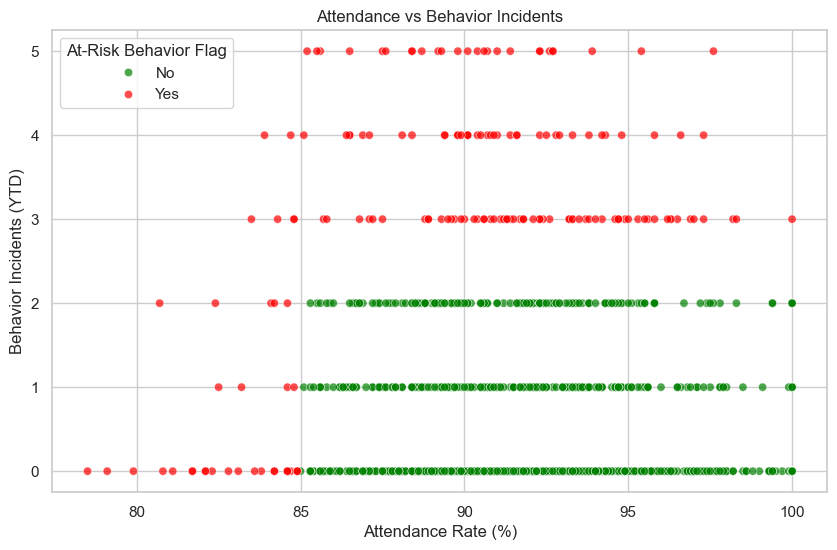

In [132]:
from pathlib import Path

plt.figure(figsize=(10,6))
try:
    # If df_diag already exists, this will do nothing; otherwise attempt robust loading.
    if "df_diag" in globals():
        df_diag
    else:
        # try known file candidates first
        candidates = []
        candidates += list(globals().get("candidate_paths") or [])
        candidates += list(globals().get("candidates_to_try") or [])
        candidates += list(globals().get("search_paths") or [])
        candidates = [Path(p) for p in candidates if p]
        students_file = next((p for p in candidates if p.exists()), None)

        if students_file:
            if students_file.suffix.lower() in (".xls", ".xlsx"):
                df_diag = pd.read_excel(students_file)
            else:
                df_diag = pd.read_csv(students_file)
            print(f"Loaded diagnostics from: {students_file}")
        else:
            # fallback: check the DB for the table before querying
            with sqlite3.connect(str(DB_PATH)) as _conn:
                tables = [t[0] for t in _conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()]
                if "student_diagnostics" in tables:
                    df_diag = pd.read_sql_query("SELECT * FROM student_diagnostics", _conn)
                    print(f"Loaded diagnostics from DB table student_diagnostics in {DB_PATH}")
                else:
                    # search known DB locations for the table and try to load it
                    candidates = [Path(DB_PATH)] + [Path(p) for p in globals().get("db_candidates", [])]
                    candidates += [Path.cwd() / "db" / "capstone.db", Path.cwd() / "schooldata.db", Path.cwd().parent / "schooldata.db"]
                    available_tables = {}
                    found_path = None
                    for candidate in candidates:
                        if not candidate or not Path(candidate).exists():
                            continue
                        try:
                            with sqlite3.connect(str(candidate)) as c2:
                                tbls = [t[0] for t in c2.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()]
                                available_tables[str(candidate)] = tbls
                                if "student_diagnostics" in tbls:
                                    found_path = candidate
                                    df_diag = pd.read_sql_query("SELECT * FROM student_diagnostics", c2)
                                    DB_PATH = Path(candidate)
                                    print(f"Loaded diagnostics from DB table student_diagnostics in {DB_PATH}")
                                    break
                        except Exception:
                            continue
                    if found_path is None:
                        # as a last resort, search the project tree for any .db that contains the table
                        project_root = globals().get("project_root", Path.cwd())
                        for candidate_db in sorted(project_root.rglob("*.db")):
                            try:
                                with sqlite3.connect(str(candidate_db)) as c3:
                                    tbls = [t[0] for t in c3.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()]
                                    available_tables[str(candidate_db)] = tbls
                                    if "student_diagnostics" in tbls:
                                        df_diag = pd.read_sql_query("SELECT * FROM student_diagnostics", c3)
                                        DB_PATH = candidate_db
                                        found_path = candidate_db
                                        print(f"Loaded diagnostics from DB table student_diagnostics in {DB_PATH}")
                                        break
                            except Exception:
                                continue
                        if found_path is None:
                            raise RuntimeError(
                                f"student_diagnostics table not found in {DB_PATH}; checked candidates and found: {available_tables}"
                            )
except NameError:
    with sqlite3.connect(str(DB_PATH)) as _conn:
        df_diag = pd.read_sql_query("SELECT * FROM student_diagnostics", _conn)

sns.scatterplot(
    data=df_diag,
    x="Attendance Rate (%)",
    y="Behavior Incidents (YTD)",
    hue="At-Risk Behavior Flag",
    palette={"Yes": "red", "No": "green"},
    alpha=0.7
)

plt.title("Attendance vs Behavior Incidents")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("Behavior Incidents (YTD)")
plt.grid(True)
plt.show()

In [150]:
import pandas as pd

In [152]:
# df_diag is already loaded from the database, no need to reload
# If you need a fresh copy, use:
df_diag = pd.read_sql_query("SELECT * FROM student_diagnostics", sqlite3.connect(str(DB_PATH)))

In [153]:
df_diag.head()
df_diag.info()
df_diag.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Student                               1000 non-null   str    
 1   Overall Placement & Scale Score       1000 non-null   str    
 2   Scale Score                           1000 non-null   int64  
 3   NO (Number and Operations)            1000 non-null   str    
 4   ALG (Algebra and Algebraic Thinking)  1000 non-null   str    
 5   MS (Measurement and Data)             1000 non-null   str    
 6   GEO (Geometry)                        1000 non-null   str    
 7   Typical Growth                        1000 non-null   int64  
 8   Stretch Growth                        1000 non-null   int64  
 9   Diagnostic Date                       1000 non-null   str    
 10  Attendance Rate (%)                   1000 non-null   float64
 11  Tardies (YTD)                

,Scale Score,Typical Growth,Stretch Growth,Attendance Rate (%),Tardies (YTD),Behavior Incidents (YTD),Positive Behavior Points,Engagement Rating (1-5),placement_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,412.717000,32.398000,45.209000,91.436600,8.592000,0.994000,25.788000,3.588000,412.717000
std,105.533579,7.407325,8.631212,3.786018,3.339864,1.305246,14.784845,1.079547,105.533579
min,101.000000,20.000000,26.000000,78.500000,0.000000,0.000000,0.000000,1.000000,101.000000
25%,359.000000,26.000000,39.000000,88.900000,6.000000,0.000000,13.000000,3.000000,359.000000
50%,419.000000,32.000000,45.000000,91.400000,9.000000,0.000000,26.000000,4.000000,419.000000
75%,487.000000,39.000000,52.000000,93.825000,11.000000,2.000000,39.000000,4.000000,487.000000
max,618.000000,45.000000,65.000000,100.000000,20.000000,5.000000,50.000000,5.000000,618.000000


In [161]:
import pandas as pd
from pathlib import Path
import sqlite3

search_files = [
    Path("../Data/Diagnostic_Results.csv"),
    Path("../data/diagnostic-results_dummy-database_with-behavior_1000rows.xlsx"),
    Path("../data/diagnostic_results.csv"),
    Path("data/diagnostic_results.csv"),
    Path("diagnostic-results.csv"),
    Path("diagnostic_results.csv"),
]
search_files += [Path(p) for p in globals().get("candidate_paths", []) if p]
search_files += [Path(p) for p in globals().get("candidates_to_try", []) if p]

students_file = next((p for p in search_files if p.exists()), None)

if students_file is not None:
    if students_file.suffix.lower() in (".xls", ".xlsx"):
        df_diag = pd.read_excel(students_file)
    else:
        df_diag = pd.read_csv(students_file)
    print(f"Loaded diagnostics from: {students_file}")
else:
    db_path = Path(globals().get("DB_PATH") or "schooldata.db")
    with sqlite3.connect(str(db_path)) as conn:
        tables = [row[0] for row in conn.execute("SELECT name FROM sqlite_master WHERE type='table';")]
        if "student_diagnostics" in tables:
            df_diag = pd.read_sql_query("SELECT * FROM student_diagnostics", conn)
            print(f"Loaded diagnostics from DB table student_diagnostics in {db_path}")
        else:
            raise FileNotFoundError(
                "Could not locate diagnostic file or student_diagnostics table. "
                f"Checked: {[str(p) for p in search_files]} and DB {db_path}"
            )


Loaded diagnostics from DB table student_diagnostics in C:\Users\pek43\Projects\Tracking-Progress-Throughout-Elementary-School\Notebooks\data\school_progress.db


In [166]:
candidates = [
    Path("../Data/School_Roster.csv"),
    Path("../data/School_Roster.csv"),
    Path("Data/School_Roster.csv"),
    Path("data/School_Roster.csv"),
    Path("School_Roster.csv"),
    Path("school_roster.csv"),
]
candidates += [Path(p) for p in (globals().get("candidate_paths") or [])]
candidates += [Path(p) for p in (globals().get("candidates_to_try") or [])]

school_roster_file = next((p for p in candidates if p.exists()), None)
if school_roster_file is None:
    for candidate in Path.cwd().resolve().rglob("*School_Roster.*"):
        if candidate.name.lower() in {
            "school_roster.csv",
            "school_roster.xlsx",
            "school_roster.xls",
        }:
            school_roster_file = candidate
            break

if school_roster_file is not None:
    if school_roster_file.suffix.lower() in (".xls", ".xlsx"):
        df_schools = pd.read_excel(school_roster_file)
    else:
        df_schools = pd.read_csv(school_roster_file)
    print(f"Loaded school roster from {school_roster_file}")
else:
    db_path = Path(globals().get("DB_PATH") or "schooldata.db")
    with sqlite3.connect(str(db_path)) as conn:
        tables = [row[0] for row in conn.execute(
            "SELECT name FROM sqlite_master WHERE type='table';"
        ).fetchall()]
        if "school_roster" in tables:
            df_schools = pd.read_sql_query("SELECT * FROM school_roster", conn)
            print(f"Loaded school roster from DB table school_roster in {db_path}")
        else:
            # try to locate school_roster in other known database files
            db_path = Path(globals().get("DB_PATH") or "schooldata.db")
            db_search_paths = [db_path]
            db_search_paths += [Path(p) for p in globals().get("db_candidates", []) if p]
            db_search_paths += [
                Path.cwd() / "schooldata.db",
                Path.cwd().parent / "schooldata.db",
                Path.cwd() / "Notebooks" / "schooldata.db",
                Path.cwd().parent / "Notebooks" / "schooldata.db",
            ]

            found_db = None
            for candidate_db in db_search_paths:
                candidate_db = Path(candidate_db)
                if not candidate_db.exists():
                    continue
                try:
                    with sqlite3.connect(str(candidate_db)) as test_conn:
                        table_names = [
                            row[0]
                            for row in test_conn.execute(
                                "SELECT name FROM sqlite_master WHERE type='table';"
                            ).fetchall()
                        ]
                    if "school_roster" in table_names:
                        found_db = candidate_db
                        break
                except Exception:
                    continue

            if found_db is None:
                project_root = Path(globals().get("project_root") or Path.cwd())
                for candidate_db in sorted(project_root.rglob("*.db")):
                    try:
                        with sqlite3.connect(str(candidate_db)) as test_conn:
                            table_names = [
                                row[0]
                                for row in test_conn.execute(
                                    "SELECT name FROM sqlite_master WHERE type='table';"
                                ).fetchall()
                            ]
                        if "school_roster" in table_names:
                            found_db = candidate_db
                            break
                    except Exception:
                        continue

            if found_db is not None:
                with sqlite3.connect(str(found_db)) as conn:
                    df_schools = pd.read_sql_query("SELECT * FROM school_roster", conn)
                print(f"Loaded school roster from DB table school_roster in {found_db}")
            else:
                fallback_roots = [project_root, project_root.parent, Path.cwd(), Path.cwd().parent]
                fallback_files = []
                for root in fallback_roots:
                    if not root.exists():
                        continue
                    fallback_files += list(root.rglob("*school*_roster*.*"))
                    fallback_files += list(root.rglob("*school*roster*.*"))

                fallback_files = [
                    p for p in dict.fromkeys(fallback_files)
                    if p.suffix.lower() in {".csv", ".xls", ".xlsx"}
                ]

In [168]:
df_diag.head()
if "df_schools" not in globals():
    print("df_schools is not defined. Searching for school_roster in known databases...")
    for candidate_db in [Path(DB_PATH)] + [Path(p) for p in globals().get("db_candidates", [])]:
        if not candidate_db.exists():
            continue
        with sqlite3.connect(str(candidate_db)) as conn:
            tables = [row[0] for row in conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()]
            if "school_roster" in tables:
                df_schools = pd.read_sql_query("SELECT * FROM school_roster", conn)
                print(f"Loaded df_schools from {candidate_db}")
                break

if "df_schools" in globals():
    df_schools.head()
else:
    print("df_schools still not available; no school_roster table found in known databases.")

df_schools is not defined. Searching for school_roster in known databases...
df_schools still not available; no school_roster table found in known databases.


In [174]:
if "df_schools" not in globals():
    roster_candidates = [
        Path("../Data/School_Roster.csv"),
        Path("../data/School_Roster.csv"),
        Path("data/School_Roster.csv"),
        Path("School_Roster.csv"),
        Path("school_roster.csv"),
    ]
    roster_file = next((p for p in roster_candidates if p.exists()), None)

    if roster_file is not None:
        if roster_file.suffix.lower() in (".xls", ".xlsx"):
            df_schools = pd.read_excel(roster_file)
        else:
            df_schools = pd.read_csv(roster_file)
    else:
        db_candidate = Path(globals().get("DB_PATH") or "schooldata.db")
        if db_candidate.exists():
            with sqlite3.connect(str(db_candidate)) as conn:
                tables = [row[0] for row in conn.execute("SELECT name FROM sqlite_master WHERE type='table';")]
                if "school_roster" in tables:
                    df_schools = pd.read_sql_query("SELECT * FROM school_roster", conn)

    if "df_schools" not in globals():
        if {"Assigned_School_Code", "Assigned_School_Name"}.issubset(df_diag.columns):
            df_schools = df_diag[["Student", "Assigned_School_Code", "Assigned_School_Name"]].drop_duplicates()
        else:
            db_search_paths = [Path(globals().get("DB_PATH") or "schooldata.db")]
            db_search_paths += [Path(p) for p in (globals().get("db_candidates") or []) if p]
            db_search_paths += [
                Path("schooldata.db"),
                Path.cwd() / "schooldata.db",
                Path.cwd().parent / "schooldata.db",
            ]

            for candidate_db in dict.fromkeys(db_search_paths):
                if not candidate_db.exists():
                    continue
                with sqlite3.connect(str(candidate_db)) as conn:
                    tables = [row[0] for row in conn.execute("SELECT name FROM sqlite_master WHERE type='table';")]
                    if "school_roster" in tables:
                        df_schools = pd.read_sql_query("SELECT * FROM school_roster", conn)
                        break

            if "df_schools" not in globals():
                # last-ditch attempt: infer a roster from school metadata tables
                for candidate_db in dict.fromkeys(db_search_paths):
                    candidate_db = Path(candidate_db)
                    if not candidate_db.exists():
                        continue

                    try:
                        with sqlite3.connect(str(candidate_db)) as conn:
                            tables = [
                                row[0]
                                for row in conn.execute(
                                    "SELECT name FROM sqlite_master WHERE type='table';"
                                ).fetchall()
                            ]

                            if "school_roster" in tables:
                                df_schools = pd.read_sql_query(
                                    "SELECT * FROM school_roster", conn
                                )
                                break

                            if "school_improvement" in tables:
                                df_tmp = pd.read_sql_query(
                                    'SELECT DISTINCT "School Code" AS Assigned_School_Code, '
                                    '"School Name" AS Assigned_School_Name '
                                    "FROM school_improvement",
                                    conn,
                                )
                                if not df_tmp.empty:
                                    df_schools = df_tmp
                                    break

                            if "school_accountability" in tables:
                                df_tmp = pd.read_sql_query(
                                    'SELECT DISTINCT "School Code" AS Assigned_School_Code, '
                                    '"School Name" AS Assigned_School_Name '
                                    "FROM school_accountability",
                                    conn,
                                )
                                if not df_tmp.empty:
                                    df_schools = df_tmp
                                    break
                    except sqlite3.DatabaseError:
                        continue

In [179]:
if "df_merged" not in globals():
    if "df_diag" in globals():
        df_merged = df_diag.copy()
    else:
        with sqlite3.connect(str(DB_PATH)) as conn:
            df_merged = pd.read_sql_query("SELECT * FROM student_diagnostics", conn)

df_merged.info()
df_merged.head()
df_merged.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Student                               1000 non-null   str    
 1   Overall Placement & Scale Score       1000 non-null   str    
 2   Scale Score                           1000 non-null   int64  
 3   NO (Number and Operations)            1000 non-null   str    
 4   ALG (Algebra and Algebraic Thinking)  1000 non-null   str    
 5   MS (Measurement and Data)             1000 non-null   str    
 6   GEO (Geometry)                        1000 non-null   str    
 7   Typical Growth                        1000 non-null   int64  
 8   Stretch Growth                        1000 non-null   int64  
 9   Diagnostic Date                       1000 non-null   str    
 10  Attendance Rate (%)                   1000 non-null   float64
 11  Tardies (YTD)                

Student                                 0
Overall Placement & Scale Score         0
Scale Score                             0
NO (Number and Operations)              0
ALG (Algebra and Algebraic Thinking)    0
MS (Measurement and Data)               0
GEO (Geometry)                          0
Typical Growth                          0
Stretch Growth                          0
Diagnostic Date                         0
Attendance Rate (%)                     0
Tardies (YTD)                           0
Behavior Incidents (YTD)                0
Positive Behavior Points                0
Engagement Rating (1-5)                 0
At-Risk Behavior Flag                   0
placement_label                         0
placement_score                         0
dtype: int64

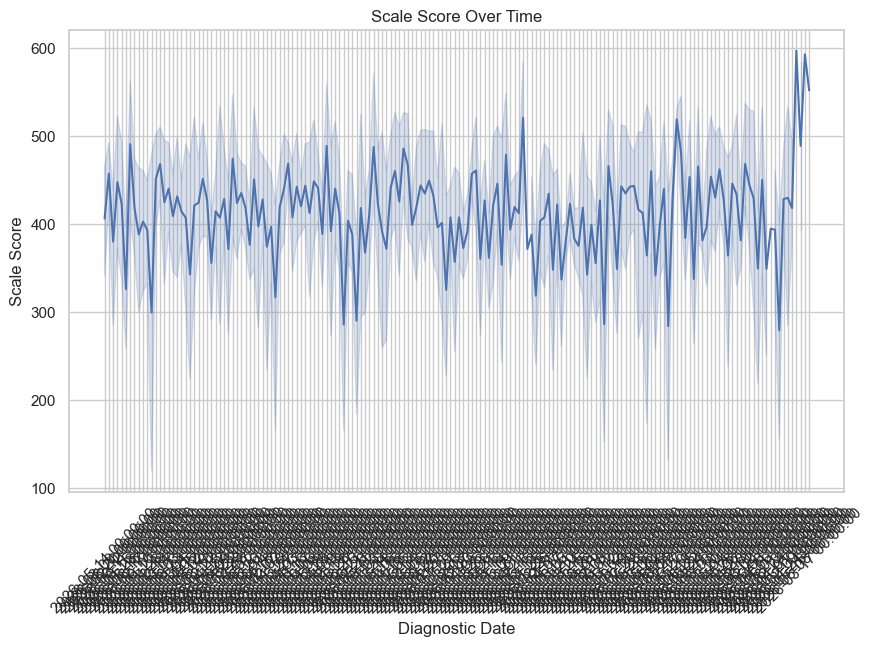

In [180]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df_merged, x="Diagnostic Date", y="Scale Score")
plt.title("Scale Score Over Time")
plt.xticks(rotation=45)
plt.show()


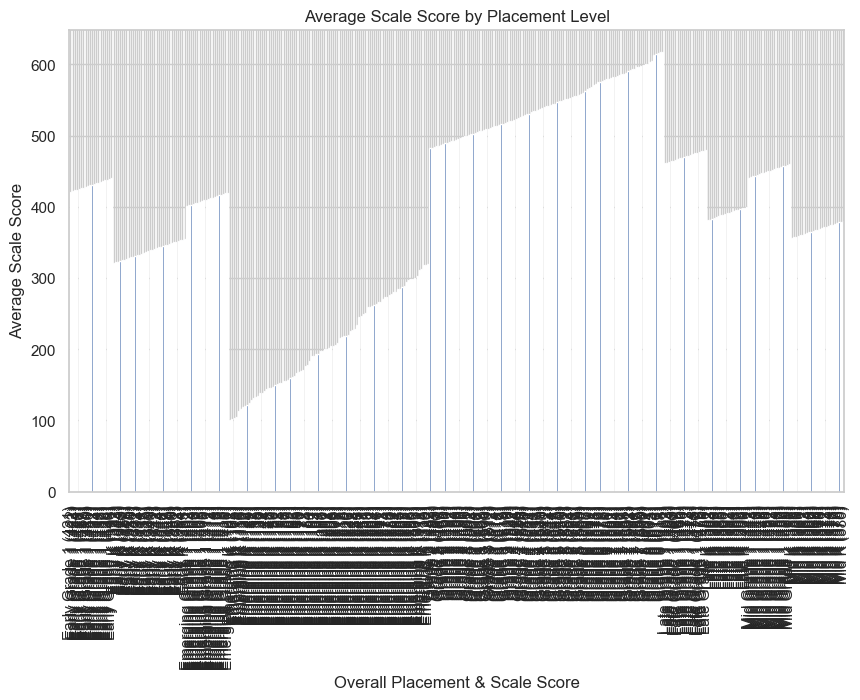

In [181]:
plt.figure(figsize=(10,6))
df_merged.groupby("Overall Placement & Scale Score")["Scale Score"].mean().plot(kind="bar")
plt.title("Average Scale Score by Placement Level")
plt.ylabel("Average Scale Score")
plt.show()


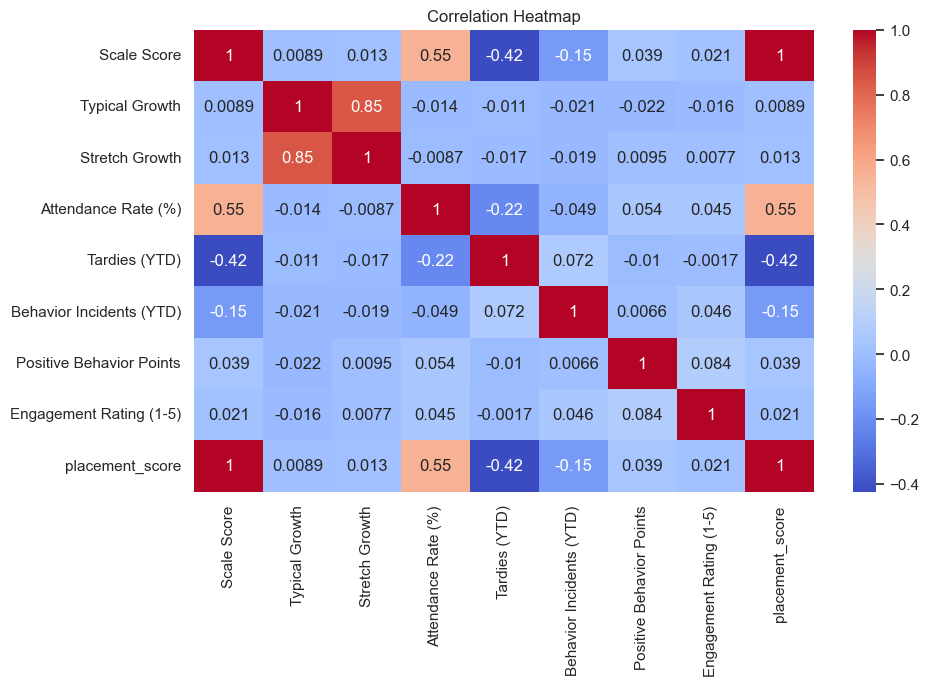

In [183]:
plt.figure(figsize=(10,6))
sns.heatmap(df_merged.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [184]:
plt.savefig("../Data/my_plot.png", dpi=300)


<Figure size 640x480 with 0 Axes>